# Lecture 10 - Regularization

## The perfect model

In [1]:
import numpy as np
import math
from matplotlib import pyplot as plt
import statsmodels.api as sm

We'll make some sinuosoidal data and add white noise, using the equation $y=\beta_0 + R \cos (2\pi ft + \phi) + \epsilon$

Text(0, 0.5, 'value')

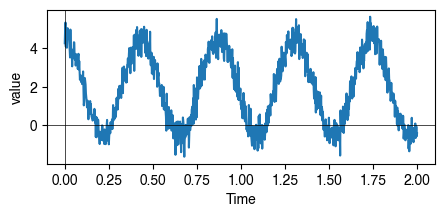

In [13]:
fs = 500 # sampling rate 
duration = 2
t = np.arange(0,duration,step=1/fs)
B0 = 2
phi = 0
f = 2.3
R =  2.5
var_eps = .2 # Variance of white noise

# Our true sinusoid
y = B0 + R*np.cos(2*math.pi*f*t + phi) + np.sqrt(var_eps)*np.random.randn(len(t))

# Let's plot it and our x and y origin lines
plt.figure(figsize=(5,2))
plt.plot(t, y)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel('Time')
plt.ylabel('value')

## Let's first find f with grid search

1000


Text(0, 0.5, 'RSS')

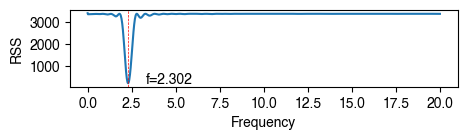

In [21]:
print(len(t))
f_grid = np.linspace(0,20,1000)

RSS = np.zeros(len(f_grid))
for idx, f_hat in enumerate(f_grid):
    cos_col = np.cos(2 * np.pi * f_hat * t )
    sin_col = np.sin(2 * np.pi * f_hat * t )
    X = np.column_stack([np.ones(len(t)), cos_col, sin_col])
    
    model = sm.OLS(y, X).fit()
    betas = model.params
    RSS[idx] = np.sum(model.resid **2)

plt.figure(figsize=(5,1))
plt.plot(f_grid, RSS,'-')
f_hat = f_grid[RSS.argmin()] # Find the best f_hat
plt.axvline(f_hat, color='r', linewidth=0.5, linestyle='--')
plt.text(f_hat + 1, np.min(RSS), f'f={f_hat:.3f}')
plt.xlabel('Frequency')
plt.ylabel('RSS')

## Use our best f to calculate the other coefficients

We will now make our X matrix as discussed in class:

$$
  X_f = \begin{pmatrix} 
    1 & \cos(2\pi \hat{f} t_0) & \sin(2\pi \hat{f} t_0) \\
    \vdots & \vdots & \vdots \\
    1 & \cos(2\pi \hat{f} t_n) & \sin(2\pi \hat{f} t_n) \\
    \end{pmatrix}
$$

and use it to calculate our $\beta$ coefficients with OLS. 

Text(0, 0.5, 'yhat')

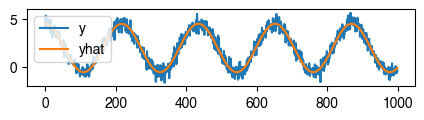

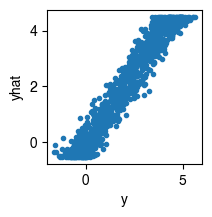

In [22]:
cos_col = np.cos(2 * np.pi * f_hat * t )
sin_col = np.sin(2 * np.pi * f_hat * t )
X = np.column_stack([np.ones(len(t)), cos_col, sin_col])

model = sm.OLS(y, X).fit()
betas = model.params
y_hat = model.fittedvalues

plt.figure(figsize=(5,1))
plt.plot(y, label='y')
plt.plot(y_hat, label='yhat')
plt.legend()

plt.figure(figsize=(2,2))
plt.plot(y, y_hat,'.')
plt.xlabel('y')
plt.ylabel('yhat')

## A Perfect Model

This sinusoidal model looks pretty good, but it doesn't perfectly fit all of the fluctuations in our data - there is still some residual variance not explained. So what if we tried to do even better by increasing the number of parameters?

One (not advised) way is to fit a model where our number of parameters is equal to our number of observations over time ($p=n$). We'll see how this can fit our data well, but still be quite problematic.

This is like doing


$$
  X = \begin{pmatrix} 
    1 & \cos(2\pi f_0 t_0) & \sin(2\pi f_0 t_0) & \cdots & \cos(2\pi f_p t_0) & \sin(2\pi f_p t_0) \\
    \vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
    1 & \cos(2\pi f_0 t_n) & \sin(2\pi f_0 t_n) & \cdots & \cos(2\pi f_p t_n) & \sin(2\pi f_p t_n) \\
    \end{pmatrix}
$$

Where we test all possible combinations of sines and cosines at various frequencies $f_0 \dots f_p$.

In [28]:
# What about if p = n

# Make a new grid of frequencies from 1 to the Nyquist limit
f_grid = np.linspace(0,fs/2,len(t)//2)
print(f_grid.shape)

cols = [np.ones(len(t))]  # intercept
for f2 in f_grid:
    cols.append(np.cos(2 * np.pi * f2 * t))
    cols.append(np.sin(2 * np.pi * f2 * t))

X_overfit_train = np.column_stack(cols)
model_overfit = sm.OLS(y,X_overfit_train).fit()

print(model_overfit.summary())

(500,)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                 -2.336
Method:                 Least Squares   F-statistic:                    0.2983
Date:                Tue, 24 Feb 2026   Prob (F-statistic):              0.965
Time:                        08:57:05   Log-Likelihood:                 474.23
No. Observations:                1000   AIC:                             1048.
Df Residuals:                       2   BIC:                             5945.
Df Model:                         997                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.097e+10   1.97e+10     -0.555  

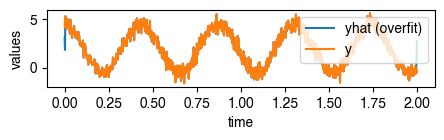

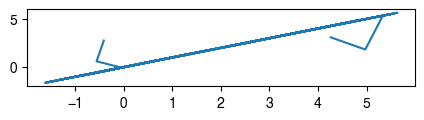

In [27]:
plt.figure(figsize=(5,1))
plt.plot(t,model_overfit.fittedvalues, label='yhat (overfit)')
plt.plot(t,y, label='y')
plt.legend()
plt.xlabel('time')
plt.ylabel('values')
plt.legend()

plt.figure(figsize=(5,1))
plt.plot(y, model_overfit.fittedvalues)

## What about new data?

This model might seem like it's fitting our data well -- we have no error! But what if we tried to use this as a predictive model to forecast new data? Let's try generating some new data in the future from the same underlying sinusoid, then use the coefficients that we fit above on our "training set" to fit the new "test set" data.

501


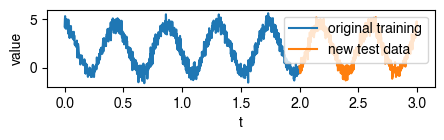

In [30]:
# Generate some new data for some new time points in the future $t2$
duration2 = 1
t2 = np.arange(t[-1],t[-1]+duration2,step=1/fs)

y_test = B0 + R*np.cos(2*math.pi*f*t2 + phi) + np.sqrt(var_eps)*np.random.randn(len(t2))

plt.figure(figsize=(5,1))
plt.plot(t, y, label='original training')
plt.plot(t2, y_test, label='new test data')
plt.legend()
plt.xlabel('t')
plt.ylabel('value')

print(len(y_test))

In [31]:
# Now let's make a new X matrix for our test data of the correct dimensions
# and calculate predictions based on this seemingly "perfect" model.

# Loop through all the same frequencies we tried before and add them to our model
cols = [np.ones(len(t2))]  # intercept
for f2 in f_grid:
    cols.append(np.cos(2 * np.pi * f2 * t2))
    cols.append(np.sin(2 * np.pi * f2 * t2))

X_overfit_test = np.column_stack(cols)
y_hat_test = np.dot(X_overfit_test, model_overfit.params)

print(X_overfit_test.shape)
print(model_overfit.params.shape)
print(y_hat_test.shape)

(501, 1001)
(1001,)
(501,)


root mean squared error on training data: 0.1505931704635737
root mean squared error on test data: 4.4126726267868985


Text(0, 0.5, 'yhat_test')

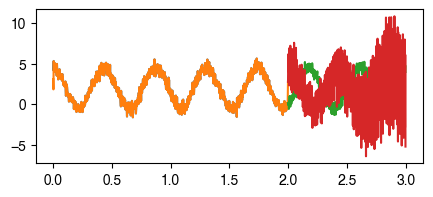

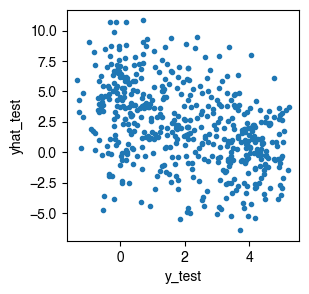

In [34]:
plt.figure(figsize=(5,2))
plt.plot(t, y, label='train')
plt.plot(t, model_overfit.fittedvalues, label='est train data (overfit)')
plt.plot(t2, y_test, label='test data')
plt.plot(t2, y_hat_test, label='est. test data (overfit)')
#plt.legend()

train_RMSE_overfit = np.sqrt(np.mean((model_overfit.resid)**2))
test_RMSE_overfit = np.sqrt(np.mean((y_test - y_hat_test)**2))
print(f'root mean squared error on training data: {train_RMSE_overfit}')
print(f'root mean squared error on test data: {test_RMSE_overfit}')

plt.figure(figsize=(3,3))
plt.plot(y_test, y_hat_test,'.')
plt.xlabel('y_test')
plt.ylabel('yhat_test')


## The results don't generalize to new data!

While we had many parameters to account for the noise in our training set, the result is that the forecasting performance is pretty terrible! We have massively overfit to noise in our training set. So what instead if we go back to our simpler 3 parameter model and look at training and test performance?

In [35]:
# Make a new X matrix with the original f_hat we estimated from the training data, and 
# use t2 as our new time observations, then calculate our new estimate of y
cos_col = np.cos(2 * np.pi * f_hat * t2 )
sin_col = np.sin(2 * np.pi * f_hat * t2 )
X = np.column_stack([np.ones(len(t2)), cos_col, sin_col])

y_hat_test_orig = np.dot(X, model.params) 

## Plot training and testing data

root mean squared error on training data: 0.44508702979915443
root mean squared error on test data: 0.4424284713076046


Text(0, 0.5, 'residual')

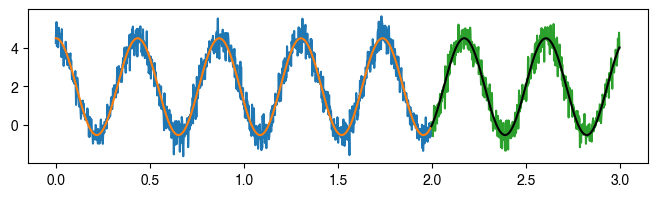

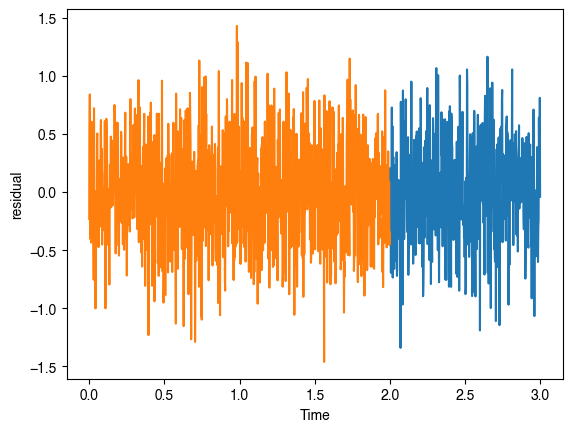

In [41]:
plt.figure(figsize=(8,2))
plt.plot(t, y)
plt.plot(t, model.fittedvalues)

plt.plot(t2, y_test)
plt.plot(t2, y_hat_test_orig, color='k')

train_RMSE = np.sqrt(np.mean((model.resid)**2))
test_RMSE = np.sqrt(np.mean((y_test - y_hat_test_orig)**2))
print(f'root mean squared error on training data: {train_RMSE}')
print(f'root mean squared error on test data: {test_RMSE}')

plt.figure()
plt.plot(t2, y_test - y_hat_test_orig)
plt.plot(t, y - y_hat)
plt.xlabel('Time')
plt.ylabel('residual')


# Cross-validation on time series data

As we discussed, it's often best to try and predict new data based on past observations rather than "cheating" by using future data to predict the past. So, choosing a way of splitting our data into training and testing should be done thoughtfully if we're working with time series.

Why can't we just split our data randomly into training and test data? Let's try by getting 80% of our data as the training set and the remaining 20% as test and then think about why this is problematic.

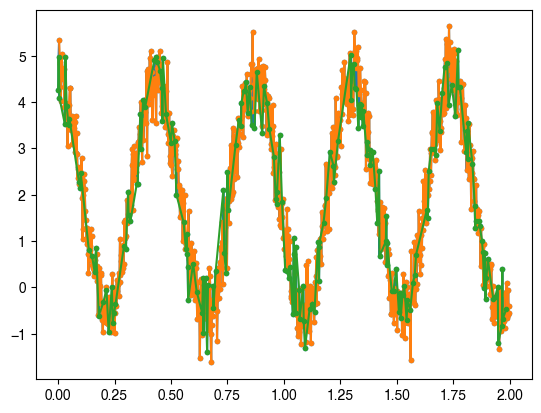

In [44]:
mask = np.zeros(len(y), dtype=bool)
mask[np.random.choice(len(y), size=int(0.8*len(y)), replace=False)] = True

# Get the training and test data through random choice of 80% of the data for training and the remainder for test
y_train = y[mask]
y_test = y[~mask]
t_train = t[mask]
t_test = t[~mask]

plt.plot(t, y,'.-')
plt.plot(t_train, y_train, '.-')
plt.plot(t_test, y_test, '.-')
#plt.gca().set_xlim([0, 0.2])

# This is cheating!

We can't do this because of the strong autocorrelations in our dataset. Randomly splitting on time indices will make your predictions falsely more accurate on your test set because your train and test data are coming from the same underlying time series and are autocorrelated with each other. 

Instead, we should split based on chunks. For example, train on the first 80% of the time samples and test on the remaining 20%. 

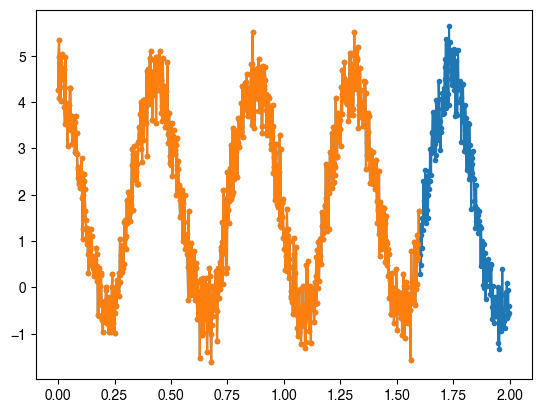

In [45]:
y_train = y[:int(0.8*len(y))]
y_test = y[int(0.8*len(y)):]
t_train = t[:int(0.8*len(y))]
t_test = t[int(0.8*len(y)):]

plt.plot(t, y,'.-')
plt.plot(t_train, y_train, '.-')

# What about choosing the number of parameters?

Here we had two straw man scenarios -- one where we have one frequency (which we know is our "true" model), and the other where we use many frequencies to perfectly approximate our training data. However, we may not always know how many frequencies we should actually choose, so we may need to search over many candidate frequencies and determine which to include in the model.

We'll try that here by testing each of the frequencies and ranking them by their individual RSS values:

[ 2.50501002  2.00400802 12.5250501   5.51102204  3.00601202  3.50701403
  1.50300601  4.00801603  5.01002004 93.68737475]


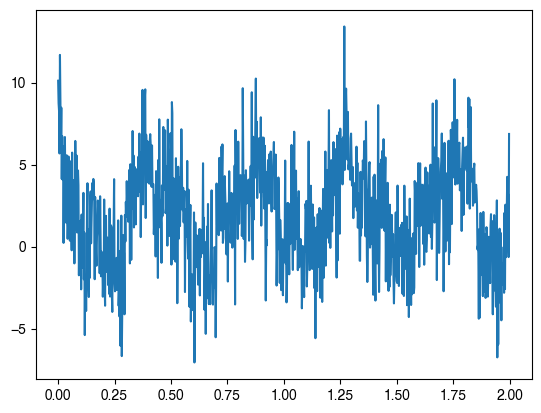

In [46]:
var_eps = 5
y2 = B0 + np.cos(2*math.pi*5.55*t + 0.12) + \
  R/2*np.cos(2*math.pi*12.5*t + 0.2) + R*np.cos(2*math.pi*f*t + phi) +\
   np.sqrt(var_eps)*np.random.randn(len(t))

plt.plot(t,y2)

rss_per_freq = []
for f_candidate in f_grid:
    X = np.column_stack([np.ones(len(t)), 
                         np.cos(2*np.pi*f_candidate*t),
                         np.sin(2*np.pi*f_candidate*t)])
    model = sm.OLS(y2, X).fit()
    rss_per_freq.append(model.ssr)

# Sort from lowest RSS to highest RSS (best to worst)
ranked_idx = np.argsort(rss_per_freq)
ranked_freqs = f_grid[ranked_idx]

print(ranked_freqs[:10])

In [ ]:
# Now CV over how many top frequencies to include
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression

cv = TimeSeriesSplit(n_splits=5)
mean_scores = []
n_freq_range = range(1, 30)

for n_freqs in n_freq_range:
    cols = [np.ones(len(t))]
    for f_k in ranked_freqs[:n_freqs]:
        cols.append(np.cos(2*np.pi*f_k*t))
        cols.append(np.sin(2*np.pi*f_k*t))
    X = np.column_stack(cols)
    scores = cross_val_score(LinearRegression(), X, y, cv=cv, 
                            scoring='neg_mean_squared_error')
    mean_scores.append(-scores.mean())

plt.plot(list(n_freq_range), mean_scores)
plt.xlabel('Number of frequencies')
plt.ylabel('CV MSE')